# Project.py

In [26]:
import logging
logging.basicConfig(
    level=logging.INFO,
    force=True,
)

import warnings
warnings.filterwarnings(action='ignore')

from polymerist.rdutils import disable_kekulized_drawing
disable_kekulized_drawing()

In [27]:
from pathlib import Path
from src.project import PolymerBuildProject, exported_to_lammps, load_job_melt_neat_topology, monomers_allowed


project_path = Path('polyID_test')
# project_path = Path('polyID_production')
project = PolymerBuildProject.get_project(project_path)

In [28]:
project.print_status(detailed=True)

Fetching status:   0%|          | 0/276 [00:00<?, ?it/s]

Fetching labels:   0%|          | 0/12 [00:00<?, ?it/s]


Overview: 12 jobs/aggregates, 2 jobs/aggregates with eligible operations.

label                           ratio
------------------------------  ----------------------------------------------------------
forcefield_is_valid             |████████████████████████████████████████| 12/12 (100.00%)
chemistry_valid                 |█████████████▎                          | 4/12 (33.33%)
chemical_info_assigned          |██████▋                                 | 2/12 (16.67%)
coordinates_generated           |██████▋                                 | 2/12 (16.67%)
energies_evaluated_lammps       |██████▋                                 | 2/12 (16.67%)
exported_to_lammps              |██████▋                                 | 2/12 (16.67%)
has_chemical_fragments          |██████▋                                 | 2/12 (16.67%)
has_interchange                 |██████▋                                 | 2/12 (16.67%)
matches_rxn_template            |██████▋                                 | 2/12 (

In [30]:
for job in project:
    print(job.doc.mechanism, job.id)

vinyl 26195721d872497384ab040c3ec8713f
imide 65f884623346352af422755cc9aaef0c
ester 82b48d89753d0ff0f03aa0a7ac242100
imide 73e632a31448fb83c1344ba3d7b6aa15
imide 1482f0d2d52918319dee067651ccfc6d
vinyl 89b515b45cb0c335231039683e3c6f6b
ester 57825dbdb6cab389c8f39ad2db3b4c1d
ester a0947aafe937dc542408a2adccf63f87
vinyl 1179463f6dfad0b75b602c8c47f0c665
ester 91cfbc42008515f5a29fcc313f293530
vinyl fb607e0e79ef559a68df7775c95fbf0e
imide 72fbb91d7739808015148ef8f3ece4f3


#### Run Jobs

In [ ]:
project.run()

In [ ]:
project.run(
    names=[
        # 'polymerize',
        # 'oligomerize',
        # 'pack_lattice',
        # 'to_interchange',
        'md_export'
    ],
    # jobs=[
    #     project.open_job(id='214e8512b6218c21668ce8c19c6bf359')
    # ]
)

## Inspect jobs

### Checking that aromaticity is being respected

In [35]:
job = project.open_job(id='57825dbdb6cab389c8f39ad2db3b4c1d')

In [46]:
from src.project import load_job_rdmol, load_job_rxn
from rdkit import Chem

rdmol = load_job_rdmol(job)
reacs = Chem.GetMolFrags(rdmol, asMols=True)
rxn = load_job_rxn(job)

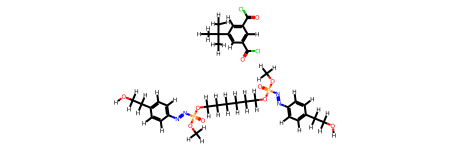

In [47]:
rdmol

In [48]:

    print(rxnname)
    print()

polyester
None
polyamide
None
polyimide
None
polycarbonate_phosgene
[<rdkit.Chem.rdchem.Mol object at 0x7f238d5dd070>, <rdkit.Chem.rdchem.Mol object at 0x7f238d5dd000>]
polycarbonate_nonphosgene
None
polyurethane_isocyanate
None
polyurethane_nonisocyanate
None
polyvinyl_head_tail
None


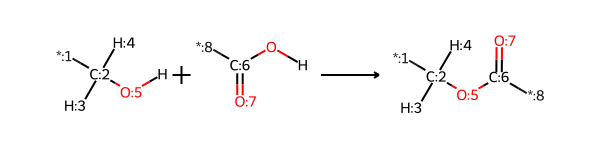

In [38]:
rxn

In [25]:
from rdkit import Chem

rxn.valid_reactant_ordering(Chem.GetMolFrags(reacs, asMols=True))

In [ ]:
from rdkit import Chem

sdf_path = job.fn(PolymerBuildProject.OLIGOMER_SDF)
sdf_path

In [ ]:
with Chem.SDMolSupplier(sdf_path) as supp:
    for mol in supp:
        display(mol)

In [ ]:
from polymerist.rdutils import set_rdkdraw_size, disable_kekulized_drawing

disable_kekulized_drawing()
set_rdkdraw_size(500, 3/2)

display(mol)

In [ ]:
import pandas as pd

records : list[dict] = []
for job in project:
    op_times = job.doc.get(PolymerBuildProject.OP_TIME_RECORD_NAME)
    if op_times is not None:
        op_times['Job ID'] = job.id
        records.append(op_times)

### Inspect multiple jobs

In [ ]:
from polymerist.genutils.decorators.functional import allow_string_paths

@allow_string_paths
def ls(path : Path) -> None:
    if not path.is_dir():
        raise NotADirectoryError
    for subpath in path.iterdir():
        print(subpath.name)

@allow_string_paths
def cat(path : Path) -> None:
    if not path.is_file():
        raise IsADirectoryError
    
    with path.open('r') as file:
        for line in file.readlines():
            print(line, end='')

In [ ]:
notable_jobs = [
    '214e8512b6218c21668ce8c19c6bf359', # stereochemistry is inverted by file write
    'a4b0a6be41f5786ff9f77f777cda59fa', # long alkane backbone hangs up partitions algorithm
    '41bc5b7d9700c043b78c0b898de4e758', # hangs with NAGL charges
]

In [ ]:
job = project.open_job(id=notable_jobs[-1])
project.get_job_status(job)

In [ ]:
offmol = load_job_oligomer_molecule(job)
offmol

In [ ]:
assign_partial_charges(job)

In [ ]:
cat(job.fn(PolymerBuildProject.LOGFILE_NAME))

In [ ]:
cat(job.fn(PolymerBuildProject.OLIGOMER_SDF))

In [ ]:
ls(job.path)

In [ ]:
with open(job.fn(PolymerBuildProject.LOGFILE_NAME), 'r') as file:
    for line in file.readlines():
        print(line)